# 03. EDA 자동화 파이프라인

## 실험 목표
- CSV 파일 경로만 입력하면 에이전트가 **자율적으로** Tool을 선택·실행
- 자연어 지시 → 에이전트가 순차적 EDA 수행 과정 관찰
- Tool 호출 로그 추적 및 중간 결과 모니터링

## 실험 흐름
```
CSV 경로 입력
    ↓
[에이전트] 데이터 개요 파악 (describe_data)
    ↓
[에이전트] 결측치 점검 (check_missing)
    ↓
[에이전트] 주요 컬럼 분포 확인 (plot_distribution)
    ↓
[에이전트] 이상치 탐지 (detect_outliers)
    ↓
[에이전트] 상관관계 분석 (correlation_matrix)
    ↓
자연어 분석 리포트 출력
```

---
## 0. 환경 준비 및 에이전트 초기화

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from dotenv import load_dotenv
from pydantic_ai import Agent, RunContext
from pydantic_ai.models.gemini import GeminiModel

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


In [2]:
# ─────────────────────────────────────────────────────────────
# Tool 함수 정의 (02 노트북에서 가져옴 — 실제 사용 시 모듈화 권장)
# ─────────────────────────────────────────────────────────────

def describe_data(df):
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    return {
        "shape": {"rows": int(df.shape[0]), "columns": int(df.shape[1])},
        "column_names": df.columns.tolist(),
        "numeric_columns": numeric_cols,
        "categorical_columns": cat_cols,
        "numeric_summary": df[numeric_cols].describe().round(2).to_dict() if numeric_cols else {},
    }

def check_missing(df):
    missing_count = df.isnull().sum()
    missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'count': missing_count, 'ratio(%)': missing_ratio})
    missing_df = missing_df.query('count > 0').sort_values('count', ascending=False)
    return {
        "total_missing_cells": int(df.isnull().sum().sum()),
        "columns_with_missing": missing_df.to_dict(orient='index')
    }

def detect_outliers(df, column):
    if column not in df.columns or not pd.api.types.is_numeric_dtype(df[column]):
        return {"error": f"'{column}' 컬럼을 처리할 수 없습니다."}
    series = df[column].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)][column]
    return {
        "column": column, "lower_bound": round(float(lower), 3),
        "upper_bound": round(float(upper), 3),
        "outlier_count": len(outliers),
        "outlier_ratio(%)": round(len(outliers) / len(series) * 100, 2),
        "outlier_values_sample": [round(float(v), 3) for v in outliers.values[:10]]
    }

def plot_distribution(df, column):
    if column not in df.columns:
        return {"error": f"'{column}' 컬럼 없음"}
    series = df[column].dropna()
    is_numeric = pd.api.types.is_numeric_dtype(series)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    if is_numeric:
        series.plot(kind='hist', bins=25, density=True, color='steelblue', alpha=0.6, ax=ax)
        series.plot(kind='kde', color='darkblue', linewidth=2, ax=ax)
        ax.axvline(series.mean(), color='red', linestyle='--', linewidth=1.5, label=f'평균 {series.mean():.1f}')
        ax.legend(fontsize=9)
        summary = {"type": "numeric", "mean": round(float(series.mean()), 2),
                   "median": round(float(series.median()), 2), "skewness": round(float(series.skew()), 3)}
    else:
        series.value_counts().head(8).plot(kind='bar', color='steelblue', ax=ax, rot=30)
        ax.set_ylabel('빈도')
        summary = {"type": "categorical", "unique_count": int(series.nunique()),
                   "top_values": series.value_counts().head(5).to_dict()}
    ax.set_title(f'{column} 분포', fontsize=12)
    plt.tight_layout()
    plt.show()
    return summary

def correlation_matrix(df, method='pearson'):
    numeric_df = df.select_dtypes(include='number')
    corr = numeric_df.corr(method=method).round(3)
    fig, ax = plt.subplots(figsize=(7, 5))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
    ax.set_title(f'상관관계 히트맵 ({method})', fontsize=12)
    plt.tight_layout()
    plt.show()
    pairs = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            pairs.append((corr.columns[i], corr.columns[j], float(corr.iloc[i, j])))
    pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    return {"method": method,
            "top_correlations": [{"col_a": a, "col_b": b, "corr": v} for a, b, v in pairs[:5]]}

print("✅ Tool 함수 5종 정의 완료")

✅ Tool 함수 5종 정의 완료


---
## 1. EDA 자동화 에이전트 구성

In [12]:
load_dotenv(override=True)
api_key = os.getenv("GEMINI_API_KEY")
gemini_model = os.getenv("GEMINI_MODEL", "gemini-3.1-flash-lite-preview")
model_id = f"google-gla:{gemini_model}"

if not api_key:
    raise ValueError(".env 파일에 GEMINI_API_KEY가 설정되어 있지 않습니다.")

print(f"✅ API 키 로드 완료")
print(f"사용 모델: {model_id}")


✅ API 키 로드 완료
사용 모델: google-gla:gemini-3.1-flash-lite-preview


In [13]:
@dataclass
class DataDeps:
    df: pd.DataFrame
    csv_path: str

eda_agent = Agent(
    model=model_id,
    deps_type=DataDeps,
    system_prompt="""
    당신은 EDA(탐색적 데이터 분석) 전문 에이전트입니다.
    
    사용자가 EDA를 요청하면 다음 순서로 반드시 모든 Tool을 활용하십시오:
    1. tool_describe_data: 데이터 개요 파악
    2. tool_check_missing: 결측치 현황 확인
    3. 수치형 컬럼 중 2개를 선택하여 tool_plot_distribution 실행
    4. Fare 또는 수치형 컬럼에 tool_detect_outliers 실행
    5. tool_correlation_matrix: 상관관계 분석
    
    모든 도구 실행 후, 분석 결과를 종합하여 한국어로 인사이트를 정리하십시오.
    각 단계마다 '▶ [단계명] 실행 중...' 형태로 진행 상황을 알려주십시오.
    """
)

@eda_agent.tool
def tool_describe_data(ctx: RunContext[DataDeps]) -> dict:
    """데이터의 기본 통계량 (형태, 컬럼 목록, 수치형 요약)을 반환합니다."""
    return describe_data(ctx.deps.df)

@eda_agent.tool
def tool_check_missing(ctx: RunContext[DataDeps]) -> dict:
    """각 컬럼의 결측치 개수와 비율을 분석합니다."""
    return check_missing(ctx.deps.df)

@eda_agent.tool
def tool_detect_outliers(ctx: RunContext[DataDeps], column: str) -> dict:
    """지정한 수치형 컬럼에서 IQR 기준으로 이상치를 탐지하고 박스플롯을 출력합니다."""
    return detect_outliers(ctx.deps.df, column)

@eda_agent.tool
def tool_plot_distribution(ctx: RunContext[DataDeps], column: str) -> dict:
    """지정한 컬럼의 분포를 시각화하고 기초 통계를 반환합니다."""
    return plot_distribution(ctx.deps.df, column)

@eda_agent.tool
def tool_correlation_matrix(ctx: RunContext[DataDeps], method: str = 'pearson') -> dict:
    """수치형 컬럼 간 상관관계 행렬을 계산하고 히트맵을 출력합니다."""
    return correlation_matrix(ctx.deps.df, method)

print("✅ EDA 에이전트 구성 완료")

✅ EDA 에이전트 구성 완료


---
## 2. EDA 자동화 실행

In [14]:
# CSV 파일 로드 및 에이전트 실행
CSV_PATH = "data/sample_data.csv"
df = pd.read_csv(CSV_PATH)
deps = DataDeps(df=df, csv_path=CSV_PATH)

print(f"📂 데이터 로드: {CSV_PATH} ({df.shape[0]}행 × {df.shape[1]}열)")
print("=" * 60)
print("🤖 EDA 에이전트 실행 시작...")
print("=" * 60)

📂 데이터 로드: data/sample_data.csv (300행 × 11열)
🤖 EDA 에이전트 실행 시작...


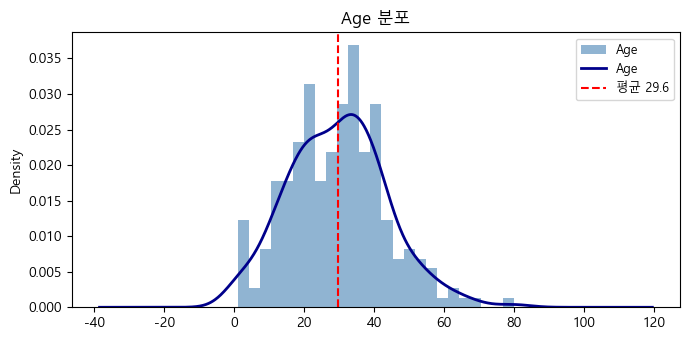

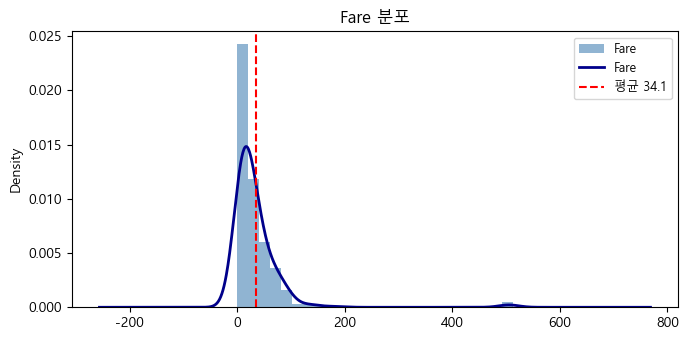

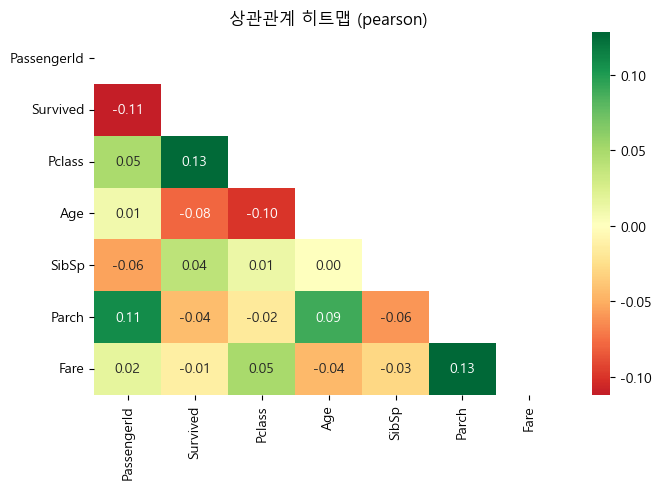


📊 EDA 에이전트 최종 분석 리포트
▶ [tool_correlation_matrix] 실행 완료.

### [EDA 분석 종합 인사이트]

1.  **데이터 품질**: 'Cabin'과 'Age'에 결측치가 상당수 존재하므로, 분석 또는 모델링 수행 전 적절한 대체(Imputation) 전략이 필요합니다.
2.  **데이터 분포**: 'Fare'는 특정 고가 요금에 의한 이상치로 인해 분포가 심하게 왜곡되어 있습니다. 이상치 처리를 수행하거나 변수 변환을 통해 정규성을 확보하는 것이 좋습니다.
3.  **상관관계**: 전반적으로 변수 간의 강력한 선형 상관관계는 관찰되지 않았습니다. 'Survived'와 'Pclass' 간의 관계가 보이긴 하지만, 계수값이 낮아 추가적인 파생 변수 생성이나 범주형 변수와의 결합 분석이 필요해 보입니다.
4.  **권장 사항**: 
    - 'Cabin' 컬럼은 결측치가 너무 많아 사용 여부를 신중히 결정해야 합니다.
    - 'Fare'의 이상치는 데이터의 실제 상황(예: 대가족 탑승)일 수 있으므로 삭제보다는 로그 변환 등의 기법을 권장합니다.


In [15]:
async def run_eda_pipeline():
    result = await eda_agent.run(
        "이 데이터에 대해 전체 EDA를 수행해주세요. "
        "데이터 개요, 결측치, 주요 컬럼 분포, 이상치, 상관관계를 순서대로 분석하십시오.",
        deps=deps
    )
    return result

eda_result = await run_eda_pipeline()

print("\n" + "=" * 60)
print("📊 EDA 에이전트 최종 분석 리포트")
print("=" * 60)
print(eda_result.output)

---
## 3. Tool 호출 로그 분석

In [10]:
# 에이전트가 어떤 Tool을 어떤 순서로 호출했는지 추적
print("[Tool 호출 순서 추적]")
print("-" * 40)

tool_calls = []
for msg in eda_result.all_messages():
    msg_type = type(msg).__name__
    if hasattr(msg, 'parts'):
        for part in msg.parts:
            part_type = type(part).__name__
            if 'ToolCall' in part_type:
                tool_calls.append(part.tool_name)
                print(f"  ▶ Tool 호출: {part.tool_name}")
            elif 'ToolReturn' in part_type:
                print(f"  ◀ 결과 반환: {part.tool_name}")

print(f"\n총 Tool 호출 횟수: {len(tool_calls)}회")
print(f"호출된 Tool 목록: {tool_calls}")

[Tool 호출 순서 추적]
----------------------------------------
  ▶ Tool 호출: tool_describe_data
  ◀ 결과 반환: tool_describe_data
  ▶ Tool 호출: tool_check_missing
  ◀ 결과 반환: tool_check_missing
  ▶ Tool 호출: tool_plot_distribution
  ◀ 결과 반환: tool_plot_distribution
  ▶ Tool 호출: tool_plot_distribution
  ◀ 결과 반환: tool_plot_distribution
  ▶ Tool 호출: tool_detect_outliers
  ◀ 결과 반환: tool_detect_outliers
  ▶ Tool 호출: tool_correlation_matrix
  ◀ 결과 반환: tool_correlation_matrix

총 Tool 호출 횟수: 6회
호출된 Tool 목록: ['tool_describe_data', 'tool_check_missing', 'tool_plot_distribution', 'tool_plot_distribution', 'tool_detect_outliers', 'tool_correlation_matrix']


---
## 4. 단계별 질문 방식 (Step-by-Step)
에이전트에게 단계별로 지시하는 방식도 실험합니다.


[Step 1] 데이터의 전반적인 구조와 기초 통계를 파악해주세요.


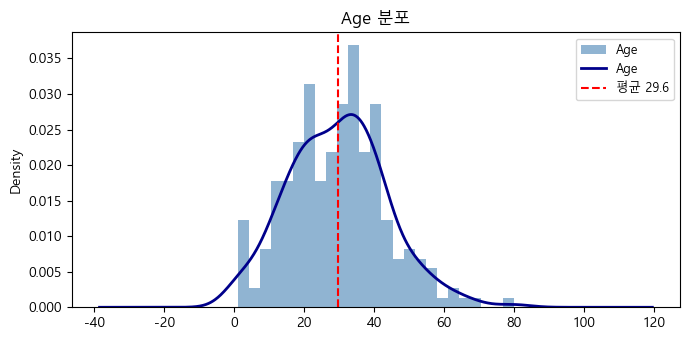

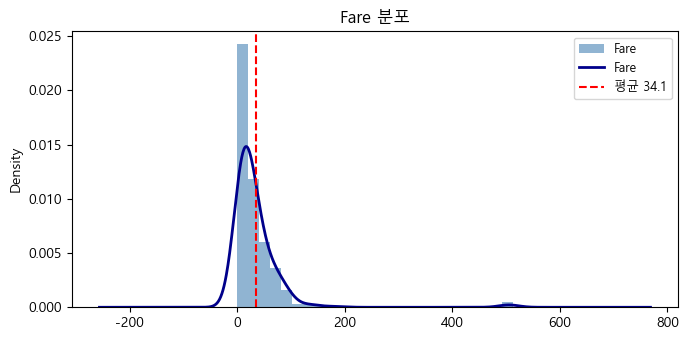

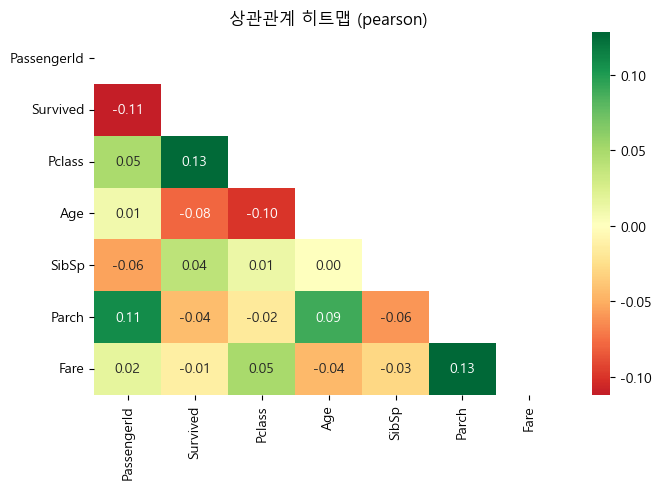

안녕하세요! 요청하신 데이터에 대한 탐색적 데이터 분석(EDA)을 모두 완료하였습니다. 진행 과정과 주요 인사이트를 정리해 드립니다.

### ▶ 진행 상황
1. **[tool_describe_data]** 데이터의 구조(300행, 11열)와 기초 통계 확인 완료
2. **[tool_check_missing]** 결측치 현황 분석 완료 (Age, Cabin 등에서 결측치 발견)
3. **[tool_plot_distribution]** Age와 Fare의 분포 확인 완료
4. **[tool_detect_outliers]** Fare 컬럼의 이상치 탐지 완료
5. **[tool_correlation_matrix]** 주요 변수 간 상관관계 분석 완료

---

### 📊 분석 인사이트

**1. 데이터 전반 및 결측치**
* 본 데이터는 총 300개의 행과 11개의 컬럼으로 구성되어 있습니다.
* 데이터의 결측치가 꽤 높은 편입니다. 특히 `Cabin`(77%)과 `Age`(약 22.7%)에서 결측치가 많이 발생하여, 향후 분석 시 이를 대체하거나 제거하는 전처리가 필수적으로 보입니다.

**2. 변수별 특성**
* **연령(`Age`):** 평균 연령은 약 29.6세로 정규 분포에 가깝게 나타납니다.
* **운임(`Fare`):** 왜도(skewness)가 6.54로 매우 높으며, 일부 고액 운임자가 존재하여 데이터가 오른쪽으로 심하게 치우쳐 있습니다. 
* **이상치:** `Fare` 컬럼에서 이상치를 탐지한 결과, 상한선($92.28)을 초과하는 이상치들이 약 4% 정도 발견되었습니다. 이 값들은 데이터 분석 시 결과에 영향을 줄 수 있으므로 주의가 필요합니다.

**3. 상관관계 분석**
* 변수 간의 전반적인 상관관계는 크지 않으나, `Pclass`와 `Survived` 간의 상관계수가 0.126으로, 객실 등급이 생존 여부와 다소 관련이 있음을 짐작할 수 있습니다. 

**추가 제언:**
`Cabin` 컬럼의 결측치가 매우 많으므로, 이 데이터를 분석에

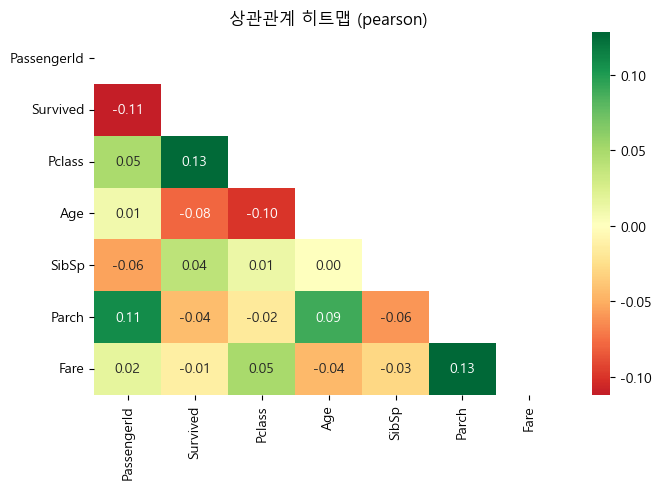

상관관계 분석 결과, `Survived`와 가장 높은 상관관계를 보이는 수치형 변수는 **`Pclass`**입니다.

상관관계 행렬 분석을 통해 확인된 주요 수치값은 다음과 같습니다.

| 관계 | 상관계수(Correlation) |
| :--- | :--- |
| **Survived - Pclass** | **0.126** |
| Survived - PassengerId | -0.112 |

### 분석 결과 해석

1.  **`Pclass`와의 관계 (0.126):** `Survived`와 가장 밀접한 수치형 변수는 객실 등급인 `Pclass`입니다. 상관계수가 양수이기는 하나, 0.126은 통계적으로 **매우 약한 양의 상관관계**를 의미합니다. 이는 등급이 낮을수록(값이 클수록) 생존 확률이 낮아지는 경향이 있음을 암시합니다.
2.  **데이터의 한계:** 현재 데이터셋의 수치형 컬럼들만으로는 `Survived`와의 상관관계가 전반적으로 낮게 나타나고 있습니다. 이는 다음 두 가지 이유로 해석할 수 있습니다.
    *   **범주형 데이터의 중요성:** `Sex`(성별), `Embarked`(탑승지)와 같은 범주형 데이터가 생존 여부에 더 큰 영향을 미칠 가능성이 큽니다.
    *   **비선형적 관계:** 상관관계 분석은 '선형적' 관계만을 측정합니다. 예를 들어, `Age`의 경우 '어린이'나 '노약자'의 생존 확률이 높은 등 특정 구간에서 생존율이 달라지는 비선형적 패턴이 존재할 수 있는데, 이런 경우에는 일반적인 피어슨 상관계수로 확인되지 않습니다.

### 향후 제안
*   **범주형 변수 확인:** 성별(`Sex`)이나 객실 등급(`Pclass`)을 범주형으로 처리한 후 생존율과의 차이를 시각화(막대 그래프 등)해 보는 것을 추천합니다. 
*   **파생 변수 생성:** `Parch`와 `SibSp`를 합쳐 `FamilySize`라는 새로운 변수를 만들면 생존율과 더 강한 상관관계를 보일 수도 있습니다.

특정 변수(예: `Sex`, `A

In [11]:
async def run_stepwise_eda():
    steps = [
        "데이터의 전반적인 구조와 기초 통계를 파악해주세요.",
        "Fare 컬럼의 이상치를 탐지하고 처리 방법을 제안해주세요.",
        "Survived와 가장 관련 있는 수치형 변수는 무엇인지 상관관계로 분석해주세요."
    ]
    
    history = None
    for i, step in enumerate(steps, 1):
        print(f"\n{'='*50}")
        print(f"[Step {i}] {step}")
        print('='*50)
        
        kwargs = {"deps": deps}
        if history:
            kwargs["message_history"] = history
        
        result = await eda_agent.run(step, **kwargs)
        history = result.new_messages()
        print(result.output)

await run_stepwise_eda()

---
## 5. 정리

### 실험 결과 요약
| 항목 | 결과 |
|---|---|
| 자동 Tool 선택 | 에이전트가 System Prompt 지시에 따라 자율 선택 |
| Tool 호출 순서 | 위 로그에서 확인 |
| 멀티턴 EDA | 대화 히스토리 유지로 문맥 연속성 확보 |

### 다음 노트북 (04)
에이전트 출력을 **pydantic.BaseModel 스키마로 구조화**하여
JSON 형태의 분석 리포트를 자동 생성하도록 개선한다.